# 03. Modeling — Regression (Cycle Life 예측)
**학습: Batch 1 / 테스트: Batch 2 (필수), Batch 3 (추가)** · 타깃 `log10(cycle_life)` · 평가 MAPE

> **Test(Batch 2)는 최종 모델을 확정한 뒤 마지막에 한 번만** 평가한다. 모델 선택·튜닝에는 Batch 1 (CV, Hold-out) 만 쓴다.

## 평가 항목별 위치 (모델 개발 및 평가)
| 평가 항목 | 세부 내용 | 이 노트북의 위치 |
|---|---|---|
| **전략 → 구현 반영** | 전략 기반으로 Feature 및 모델 구현 | **9. 전략 → 구현 반영**, 2. 후보 모델 비교 |
| **Pipeline 개발** | 개발 파이프라인 | **0. 파이프라인 구조와 핵심 변수** |
| | 데이터 분할 적절성 | **1. 분할** |
| | 핵심 변수 구현 | **0. 파이프라인 구조와 핵심 변수** (`dq_logvar`), 2-1 |
| **성능 리포팅 및 해석** | 성능 정리 (포맷 기반) | **5. 성능표** |
| | 목표 성능 대비 Gap 해석 | **5. 성능표** 아래 "성능 해석" |
| **분석 결과 해석** | 도메인 관점 해석 | **10. 도메인 관점 해석과 개발 한계점** |
| | 개발 한계점 도출 | **10. 도메인 관점 해석과 개발 한계점** |

## 0. 파이프라인 구조와 핵심 변수
```
.mat ─▶ [preprocess] 캐시 + 분석 대상 셀 정의 ─▶ [features] 셀 단위 피처 표 ─▶ [분할] Batch 1 을 프로토콜 단위로 학습 / Hold-out
     ─▶ [Pipeline] 결측 대치 ─▶ 스케일링 ─▶ 모델 (타깃 log10) ─▶ [평가] MAPE
```
- **코드** : `src/preprocess.py` → `src/features.py` → `src/train.py`(분할·Pipeline·평가) / `src/models.py`(후보 모델)
- **핵심 변수** : `dq_logvar` = log10( Var[ Qdlin(사이클 100) − Qdlin(사이클 10) ] ) — `src/features.py` 의 `dq_features`. 같은 셀 안의 차이라 셀·배치 간 정보를 쓰지 않고, 배치마다 다른 `Qdlin` 시작점이 상쇄된다.
- **누수 방지** : 분할을 가장 먼저 한다 · 결측 대치와 스케일링은 Pipeline 안에서 학습 데이터로만 fit · 같은 충전 프로토콜은 학습과 검증에 나누지 않는다(GroupKFold, GroupShuffleSplit) · 타깃에서 파생된 피처는 없다 · Batch 2 는 최종 모델 확정 뒤 한 번만 평가한다.
- **재현성** : `random_state=42` (`src/train.py`)를 분할과 모델 초기화에 모두 적용하고, 첫 셀에서 라이브러리 버전을 출력한다.

In [1]:
import sys, platform, random
from pathlib import Path
ROOT = Path.cwd().parent            # notebooks/ 안에서 실행한다고 가정 (프로젝트 루트 = 한 단계 위)
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, scipy, sklearn
from src.train import RANDOM_STATE
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)      # 무작위성이 있는 모든 곳에 같은 seed

# 환경·버전 기록 (재현성)
print('python', platform.python_version(), '| numpy', np.__version__, '| pandas', pd.__version__,
      '| scipy', scipy.__version__, '| scikit-learn', sklearn.__version__, '| RANDOM_STATE', RANDOM_STATE)

python 3.11.15 | numpy 2.4.6 | pandas 3.0.6 | scipy 1.17.1 | scikit-learn 1.9.1 | RANDOM_STATE 42


In [2]:
from src.preprocess import load_cells, build_cohort
from src.features import build_feature_table
from src.train import (get_labeled, split_holdout, group_cv, cv_mape, build_pipeline, mape,
                       performance_table, fit_final, evaluate_on, CORE_FEATURES, TARGET, PAPER_TARGET_MAPE)

feat = build_feature_table(build_cohort(load_cells()))
b1, b2, b3 = (get_labeled(feat, b) for b in ['b1', 'b2', 'b3'])
print('수명 있는 셀: Batch 1', len(b1), '/ Batch 2', len(b2), '/ Batch 3', len(b3))

수명 있는 셀: Batch 1 46 / Batch 2 39 / Batch 3 44


## 1. 분할 (가장 먼저) — Batch 1 을 프로토콜 단위로 학습 / Hold-out

In [3]:
train, holdout = split_holdout(b1)
print('학습', len(train), '/ Hold-out', len(holdout), '| 프로토콜 겹침:', len(set(train.policy) & set(holdout.policy)))

학습 35 / Hold-out 11 | 프로토콜 겹침: 0


## 2. 후보 모델 비교 — Train (Batch 1 CV) 과 Valid (Batch 1 Hold-out) 만 사용
(분석 전략: 주력 Elastic Net / Ridge, 비교군 Random Forest · XGBoost/LightGBM, 대안 PLS, 선택 Gaussian Process, 기준선 평균·단일 피처)

### 2-1. 기준선
- **평균 예측** : 피처 없이 학습 셀 수명의 기하평균만 예측 → 모델이 이보다 나아야 의미가 있다
- **핵심 피처 1개 + Elastic Net** : `dq_logvar` (EDA 에서 세 배치 모두 부호가 일관된 유일한 피처)

> 이 셀들은 Batch 1 안에서만 평가한다. Batch 2 는 사용하지 않는다.

In [4]:
from src.train import holdout_mape, mean_baseline

features = CORE_FEATURES                       # ['dq_logvar']

# 1) 평균 예측 (피처 없음) — 프로토콜 단위 CV 의 각 폴드에서 '그 폴드의 학습 부분' 평균으로 예측
naive_cv = float(np.mean([mean_baseline(train.loc[tr], train.loc[va]) for tr, va in group_cv(train)]))
naive_ho = mean_baseline(train, holdout)

# 2) 핵심 피처 1개 + Elastic Net
cv_mean, cv_scores = cv_mape(train, features)
ho = holdout_mape(train, holdout, features)

import pandas as pd
base = pd.DataFrame({'Train (Batch 1 CV)': [naive_cv, cv_mean], 'Valid (Batch 1 Hold-out)': [naive_ho, ho]},
                    index=['평균 예측', f'{features} + Elastic Net']).round(2)
print('MAPE (%)'); print(base); print('\nCV 폴드별:', [round(s, 1) for s in cv_scores])

MAPE (%)
                             Train (Batch 1 CV)  Valid (Batch 1 Hold-out)
평균 예측                                     19.21                     16.08
['dq_logvar'] + Elastic Net                7.40                     21.20

CV 폴드별: [4.9, 10.5, 9.4, 5.7, 6.6]


### 2-2. 민감도 분석 — 라벨 불확실 셀 제외
기록상 마지막 용량이 0.95 Ah 이상인 셀(Batch 1 의 8셀: b1c0·1·2·3·4·8·10·22)은 기록만으로 수명 라벨(EOL 0.88 Ah)을 검증할 수 없다. 이 셀이 결과에 얼마나 영향을 주는지 보기 위해, 전체 결과(2-1)와 이 셀을 학습·평가에서 제외한 결과를 나란히 비교한다. Hold-out 분할은 바꾸지 않고, 같은 분할에서 해당 셀만 제거한다.

In [5]:
tr_c = train[~train.label_uncertain].reset_index(drop=True)
ho_c = holdout[~holdout.label_uncertain].reset_index(drop=True)
print(f'라벨 불확실 셀: 학습 {train.label_uncertain.sum()}/{len(train)}, Hold-out {holdout.label_uncertain.sum()}/{len(holdout)}'
      f'  ->  제외 후 학습 {len(tr_c)}셀, Hold-out {len(ho_c)}셀')

naive_cv_c = float(np.mean([mean_baseline(tr_c.loc[a], tr_c.loc[b]) for a, b in group_cv(tr_c)]))
naive_ho_c = mean_baseline(tr_c, ho_c)
cv_c, cv_scores_c = cv_mape(tr_c, features)
ho_c_mape = holdout_mape(tr_c, ho_c, features)

sens = pd.DataFrame({
    '전체 : Train CV': [naive_cv, cv_mean], '전체 : Valid': [naive_ho, ho],
    '불확실 셀 제외 : Train CV': [naive_cv_c, cv_c], '불확실 셀 제외 : Valid': [naive_ho_c, ho_c_mape]},
    index=['평균 예측', f'{features} + Elastic Net']).round(2)
print('MAPE (%)'); print(sens)

라벨 불확실 셀: 학습 5/35, Hold-out 3/11  ->  제외 후 학습 30셀, Hold-out 8셀
MAPE (%)
                             전체 : Train CV  전체 : Valid  불확실 셀 제외 : Train CV  \
평균 예측                                19.21       16.08                19.03   
['dq_logvar'] + Elastic Net           7.40       21.20                 8.15   

                             불확실 셀 제외 : Valid  
평균 예측                                    9.26  
['dq_logvar'] + Elastic Net             10.60  


### 2-3. 피처 조합과 모델 비교 (Batch 1 안에서만)
- 피처 조합 : 핵심 `dq_logvar` / 핵심 + **전압 구간별 ΔQ 분산**(파생변수) / 구간 분산만 / 핵심 + 요약값(`QD_slope`, `IR`, `Tavg`) / 핵심 + 충전(`C1`, `switch`)
- 모델 : Elastic Net(주력), Ridge, PLS, Random Forest, Gradient Boosting, XGBoost, LightGBM, Gaussian Process
  (XGBoost·LightGBM 은 OpenMP 런타임이 필요하다. macOS 는 `brew install libomp`)
- 선택 기준(미리 정함) : **Train CV MAPE 가 가장 낮은 조합**을 우선하되, 피처가 많은 조합은 단순한 조합보다 CV 가 뚜렷하게(1%p 이상) 낮을 때만 채택한다. Hold-out 은 표본이 작아 참고로만 본다.

In [6]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from src.train import PLS1D
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RS = RANDOM_STATE
models = {
    'ElasticNet':       lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RS, max_iter=50000),
    'Ridge':            lambda: Ridge(alpha=1.0, random_state=RS),
    'PLS':              lambda: PLS1D(n_components=1),
    'RandomForest':     lambda: RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=3, random_state=RS),
    'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, subsample=0.8, random_state=RS),
    'XGBoost':          lambda: XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, subsample=0.8, random_state=RS, n_jobs=1),
    'LightGBM':         lambda: LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, num_leaves=4, min_child_samples=3, subsample=0.8, subsample_freq=1, random_state=RS, n_jobs=1, verbose=-1),
    'GaussianProcess':  lambda: GaussianProcessRegressor(kernel=ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.1), normalize_y=True, random_state=RS),
}
bins = ['dqv_33_31', 'dqv_31_29', 'dqv_29_26', 'dqv_26_20']
feature_sets = {
    '핵심': ['dq_logvar'],
    '핵심+구간분산': ['dq_logvar'] + bins,
    '구간분산만': bins,
    '핵심+요약값': ['dq_logvar', 'QD_slope', 'IR', 'Tavg'],
    '핵심+충전': ['dq_logvar', 'C1', 'switch'],
}
runs = [('핵심', m) for m in models] + [(f, m) for f in list(feature_sets)[1:] for m in ('ElasticNet', 'Ridge')]

def evaluate(fs_name, m_name):
    feats, mk = feature_sets[fs_name], models[m_name]
    return {'피처': fs_name, '모델': m_name,
            'Train CV': cv_mape(train, feats, mk())[0], 'Valid': holdout_mape(train, holdout, feats, mk()),
            'Train CV (불확실 제외)': cv_mape(tr_c, feats, mk())[0], 'Valid (불확실 제외)': holdout_mape(tr_c, ho_c, feats, mk())}

exp = pd.DataFrame([evaluate(f, m) for f, m in runs]).round(2).sort_values('Train CV').reset_index(drop=True)
exp.to_csv(ROOT / 'results' / 'experiments.csv', index=False)
print(f'MAPE (%)  — 평균 예측 기준선: Train CV {naive_cv:.2f} / Valid {naive_ho:.2f} (불확실 제외 {naive_cv_c:.2f} / {naive_ho_c:.2f})')
exp

MAPE (%)  — 평균 예측 기준선: Train CV 19.21 / Valid 16.08 (불확실 제외 19.03 / 9.26)


,피처,모델,Train CV,Valid,Train CV (불확실 제외),Valid (불확실 제외)
0,핵심+충전,Ridge,7.03,19.59,8.69,10.51
1,핵심,PLS,7.23,23.57,8.08,10.94
2,핵심+충전,ElasticNet,7.29,20.87,8.23,10.64
3,핵심,Ridge,7.30,22.52,8.07,10.78
4,핵심,ElasticNet,7.40,21.20,8.15,10.60
5,핵심+요약값,ElasticNet,7.59,22.07,8.34,12.21
6,구간분산만,ElasticNet,7.66,21.80,7.51,7.72
7,구간분산만,Ridge,7.91,23.84,7.85,8.36
8,핵심+구간분산,ElasticNet,7.93,21.45,7.55,8.12
9,핵심+구간분산,Ridge,7.99,23.32,7.87,8.37


## 3. 최종 모델 확정 → Valid (Hold-out) 확인
**최종 모델 : 핵심 피처 `dq_logvar` + Elastic Net** (선택 근거는 2-3 와 `results/experiment_log.md`). Valid 는 Batch 1 학습 셀(35셀)로 학습한 모델로 Hold-out 을 평가한 값이고, Test 는 같은 하이퍼파라미터로 Batch 1 전체(46셀)를 다시 학습한 모델로 평가한다.

In [7]:
final_features = CORE_FEATURES                               # ['dq_logvar']
est_train = fit_final(train, final_features)                 # Valid 용: Batch 1 학습 35셀
valid_mape, valid_tbl = evaluate_on(est_train, holdout, final_features)
print(f'Train (Batch 1 CV) {cv_mean:.2f}%  |  Valid (Batch 1 Hold-out) {valid_mape:.2f}%')

Train (Batch 1 CV) 7.40%  |  Valid (Batch 1 Hold-out) 21.20%


## 4. Test (Batch 2) — 최종 모델로 **한 번만** 평가
> 아래 셀은 모델을 확정한 뒤 **한 번만** 실행한다. 결과를 보고 모델·피처·분할을 바꾸지 않는다.

평가는 `results/experiment_log.md` 3번에 미리 적어 둔 방식을 따른다 : ① 최종 모델 1개, ② 보조로 라벨 불확실 8셀을 뺀 학습(민감도)과 비교군 모델(참고용, 모델 선택에는 사용하지 않음).

In [8]:
est_final = fit_final(b1, final_features)                    # Batch 1 수명이 있는 46셀로 학습
test_b2, b2_tbl = evaluate_on(est_final, b2, final_features)
naive_b2 = mean_baseline(b1, b2)
print(f'Test (Batch 2) MAPE {test_b2:.2f}%   (평균 예측 {naive_b2:.2f}%)')

Test (Batch 2) MAPE 38.32%   (평균 예측 67.09%)


In [9]:
# 보조 보고 (참고용 · 모델 선택에는 사용하지 않음. XGBoost·LightGBM 은 Test 평가 뒤에 비교군에 추가)
b1_c = b1[~b1.label_uncertain].reset_index(drop=True)
ref = {'최종 모델 (Elastic Net)': test_b2,
       '최종 모델, 라벨 불확실 8셀 제외 학습': evaluate_on(fit_final(b1_c, final_features), b2, final_features)[0],
       '평균 예측': naive_b2}
for name in ['GaussianProcess', 'GradientBoosting', 'XGBoost', 'LightGBM', 'RandomForest']:
    ref[f'참고: {name}'] = evaluate_on(fit_final(b1, final_features, models[name]()), b2, final_features)[0]
pd.Series(ref, name='Test (Batch 2) MAPE (%)').round(2).to_frame()

,Test (Batch 2) MAPE (%)
최종 모델 (Elastic Net),38.32
"최종 모델, 라벨 불확실 8셀 제외 학습",30.31
평균 예측,67.09
참고: GaussianProcess,28.87
참고: GradientBoosting,33.50
참고: XGBoost,35.00
참고: LightGBM,32.21
참고: RandomForest,33.48


## 5. 성능표 (과제 Format) → `results/model_performance.csv`
Gap 은 오차가 커질수록 (+) 가 되도록 계산한다 (Train-Valid = Valid − Train, Valid-Test = Test − Valid, Target-Test = Test − 9.1).

In [10]:
perf = performance_table(cv_mean, valid_mape, test_b2)
perf.to_csv(ROOT / 'results' / 'model_performance.csv', index=False, encoding='utf-8-sig')
perf

,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.40,
1,Valid (Batch 1 Hold-out),21.20,
2,Test (Batch 2),38.32,
3,Gap (Train-Valid),13.80,(+) : 과적합 의심
4,Gap (Valid-Test),17.12,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),29.22,(+) : 원논문보다 오차가 큼 / Target : 원논문 9.1%


### 성능 해석 (목표 대비 Gap)
- **Gap (Train-Valid) +13.80** : 과적합처럼 보이지만 Hold-out 11셀 중 3셀(b1c0·1·2, 수명 약 1,180)이 원인이다. 이 셀들은 ΔQ 분산이 학습 범위 밖이고 수명 라벨도 검증되지 않아, 라벨 불확실 8셀을 빼면 Train 8.15 / Valid 10.60 (Gap +2.45)이다.
- **Gap (Valid-Test) +17.12** : Batch 2 에서 오차가 크게 늘어 배치 간 일반화가 떨어진다. 평균 예측(67.09%)보다는 크게 낫다.
- **Gap (Target-Test) +29.22%p** : 원논문 9.1% 대비 Batch 2 는 38.32% (약 4.2배)이다. 이 데이터에서는 Batch 2 셀의 77%가 Batch 1 수명 범위 밖이고, Batch 2 안의 신규구조 셀 9개는 12.8% 로 목표에 가깝다. Gap 은 오차가 커질수록 (+) 로 표기했다.

## 6. 오류 분석 (Batch 2)
모델이 가장 크게 틀린 셀의 공통점을 셀 구조와 학습 범위로 나눠서 확인한다. 오차는 (예측 − 실제) / 실제 이며 (+) 는 과대예측이다.

전체 평균 편향 36.2%  (+ : 과대예측)

      셀수  MAPE    편향  수명_중앙값
구조                          
기존구조  30  46.0  46.0   451.0
신규구조   9  12.8   3.7   904.0

       셀수  MAPE    편향  수명_중앙값
학습 범위                        
범위 밖   12  39.4  39.4   434.0
범위 안   27  37.8  34.8   492.0

가장 크게 틀린 8셀
  cid          policy   구조  cycle_life  pred  err_pct  dq_logvar
 b2c6     3.6C(9%)-5C 기존구조       393.0 744.3     89.4       -3.7
 b2c2 5.2C(50%)-4.25C 기존구조       424.0 720.3     69.9       -3.6
b2c15     3.6C(9%)-5C 기존구조       396.0 663.4     67.5       -3.4
b2c19      6C(60%)-3C 기존구조       392.0 628.4     60.3       -3.3
b2c18 5.2C(50%)-4.25C 기존구조       449.0 712.8     58.8       -3.6
b2c21      6C(60%)-3C 기존구조       408.0 639.4     56.7       -3.3
b2c29    5.2C(58%)-4C 기존구조       452.0 685.6     51.7       -3.5
b2c28  4.8C(80%)-4.8C 기존구조       437.0 662.7     51.6       -3.4


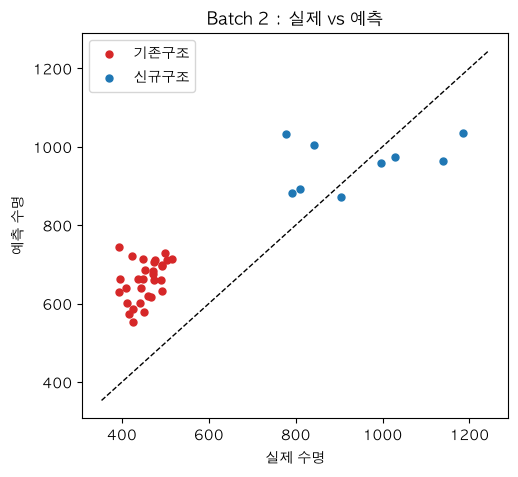

In [11]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False})

lo, hi = b1.dq_logvar.min(), b1.dq_logvar.max()
b2_tbl['구조'] = b2_tbl.newstructure.map({False: '기존구조', True: '신규구조'})
b2_tbl['학습 범위'] = np.where(b2_tbl.dq_logvar.between(lo, hi), '범위 안', '범위 밖')

print('전체 평균 편향 %.1f%%  (+ : 과대예측)' % b2_tbl.err_pct.mean())
for col in ['구조', '학습 범위']:
    g = b2_tbl.groupby(col).agg(셀수=('cid', 'count'), MAPE=('abs_err_pct', 'mean'), 편향=('err_pct', 'mean'), 수명_중앙값=('cycle_life', 'median'))
    print(); print(g.round(1))
print('\n가장 크게 틀린 8셀'); print(b2_tbl.head(8)[['cid', 'policy', '구조', 'cycle_life', 'pred', 'err_pct', 'dq_logvar']].round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(5.5, 5))
for name, col in [('기존구조', '#d62728'), ('신규구조', '#1f77b4')]:
    s = b2_tbl[b2_tbl['구조'] == name]; ax.scatter(s.cycle_life, s.pred, s=25, color=col, label=name)
lim = [b2_tbl.cycle_life.min() * 0.9, max(b2_tbl.cycle_life.max(), b2_tbl.pred.max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=1); ax.set(xlabel='실제 수명', ylabel='예측 수명', title='Batch 2 : 실제 vs 예측'); ax.legend(); plt.show()

### 오류 분석 해석
- 가장 크게 틀린 8셀은 모두 Batch 2 **기존구조 셀**이고 전부 과대예측이다(+52~+89%). 기존구조 30셀 MAPE 46.0%(편향 +46.0%), 신규구조 9셀 12.8%(편향 +3.7%).
- 기존구조 셀 중 ΔQ 분산이 Batch 1 학습 범위 **안**인 18셀도 MAPE 50.3% 이므로 외삽만으로는 설명되지 않는다. 같은 ΔQ 분산에서 이 셀들의 수명이 Batch 1 보다 짧은, **관계의 이동**으로 보인다 (원인은 이 데이터로 확정할 수 없다).
- 개선 방향 : 구조·배치 차이를 설명하는 정보를 입력에 넣거나 구조별로 관계를 따로 두기 / 포화 구간을 다루는 비선형 모델·변환 / 라벨 불확실 셀 처리 규칙을 학습 전에 정하기 / 배치 단위 검증으로 모델 고르기.

## 7. (추가) Batch 3 평가
같은 최종 모델로 평가하고 Batch 2 와 나란히 비교한다. Batch 3 은 수명 분포가 다르고(장수명 셀이 많음), 배치마다 `Qdlin` 곡선의 시작점이 달라 셀 간 단순 비교는 왜곡될 수 있다. 이 분석의 ΔQ(V) 는 **같은 셀 안의 사이클 100 − 사이클 10 차이**라 시작점 차이가 상쇄된다. 수명 미도달 2셀은 라벨이 없어 제외했다.

In [12]:
test_b3, b3_tbl = evaluate_on(est_final, b3, final_features)
print(f'Test (Batch 3) MAPE {test_b3:.2f}%   (평균 예측 {mean_baseline(b1, b3):.2f}%)   |   Batch 2 : {test_b2:.2f}%')

b3_tbl['학습 최대 초과'] = np.where(b3_tbl.cycle_life > b1.cycle_life.max(), '초과', '이내')
g = b3_tbl.groupby('학습 최대 초과').agg(셀수=('cid', 'count'), MAPE=('abs_err_pct', 'mean'), 편향=('err_pct', 'mean'))
print(); print(g.round(1))
print('\n가장 크게 틀린 5셀'); print(b3_tbl.head(5)[['cid', 'policy', 'cycle_life', 'pred', 'err_pct', 'dq_logvar']].round(1).to_string(index=False))

perf_b3 = performance_table(cv_mean, valid_mape, test_b2, test_b3)
perf_b3.to_csv(ROOT / 'results' / 'model_performance.csv', index=False, encoding='utf-8-sig')
perf_b3

Test (Batch 3) MAPE 13.98%   (평균 예측 21.15%)   |   Batch 2 : 38.32%

          셀수  MAPE    편향
학습 최대 초과                
이내        35   9.9  -2.5
초과         9  29.8 -29.8

가장 크게 틀린 5셀
  cid         policy  cycle_life   pred  err_pct  dq_logvar
b3c38     5C(67%)-4C      1935.0  988.6    -48.9       -4.3
 b3c7 4.8C(80%)-4.8C      1836.0 1055.4    -42.5       -4.5
b3c45 4.8C(80%)-4.8C      1801.0 1063.6    -40.9       -4.5
b3c42 4.8C(80%)-4.8C      1642.0 1009.5    -38.5       -4.4
b3c16 4.8C(80%)-4.8C      1638.0 1149.8    -29.8       -4.7


,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.40,
1,Valid (Batch 1 Hold-out),21.20,
2,Test (Batch 2),38.32,
3,Gap (Train-Valid),13.80,(+) : 과적합 의심
4,Gap (Valid-Test),17.12,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),29.22,(+) : 원논문보다 오차가 큼 / Target : 원논문 9.1%
6,Test (Batch 3),13.98,추가 검증 (선택)
7,Gap (Batch2-Batch3),-24.34,(+) : Batch 3 의 오차가 더 큼 (Test 성능 간 비교)
8,Gap (Target-Test) [Batch 3],4.88,"Batch 3 기준, 원논문 성능 비교"


### Batch 3 해석
- Batch 3 MAPE 13.98% (평균 편향 −8.0%) — Batch 2(38.32%)보다 낫다. 수명 분포가 달라도 오차가 작은 것은 "같은 ΔQ 분산에서 수명이 얼마나 짧아지는가"가 Batch 1 과 비슷하기 때문으로 보인다.
- 학습 최대 수명(1,227)을 넘는 9셀은 MAPE 29.8%(전부 과소예측), 범위 이내 35셀은 9.9% — 장수명 셀을 짧게 예측한다.

## 8. 앙상블 비교 (Batch 1 안에서만)
여러 모델의 예측을 평균하면 개별 모델의 약점(선형 모델은 극단 구간 과대예측, 트리 모델은 학습 범위 밖 예측 불가)이 서로 보완될 수 있는지 확인한다.

- 앙상블 : 선택한 모델들의 `log10` 스케일 예측을 **단순 평균** (`VotingRegressor`). 스태킹은 내부 CV 에서 같은 프로토콜의 셀이 나뉘는 누수 위험이 있어 쓰지 않는다.
- 평가 : 2-3 과 같은 분할(프로토콜 단위 Hold-out, GroupKFold CV). **Batch 2·3 은 사용하지 않는다.**
- 채택 기준(2-3 과 동일, 미리 정함) : Train CV MAPE 가 최종 모델(핵심 피처 + Elastic Net)보다 **1%p 이상 낮을 때만** 채택한다.

In [ ]:
from src.models import average_ensemble

cands = {
    'Elastic Net (최종, 단일)':            models['ElasticNet'],
    '앙상블: Elastic Net + GP':             average_ensemble(['ElasticNet', 'GaussianProcess'], models),
    '앙상블: Elastic Net + GP + GB':        average_ensemble(['ElasticNet', 'GaussianProcess', 'GradientBoosting'], models),
    '앙상블: 부스팅 3종 (GB, XGB, LGBM)':    average_ensemble(['GradientBoosting', 'XGBoost', 'LightGBM'], models),
    '앙상블: 8개 전체 평균':                 average_ensemble(list(models), models),
}
rows = []
for name, mk in cands.items():
    f = CORE_FEATURES
    rows.append({'모델': name, 'Train CV': cv_mape(train, f, mk())[0], 'Valid': holdout_mape(train, holdout, f, mk()),
                 'Train CV (불확실 제외)': cv_mape(tr_c, f, mk())[0], 'Valid (불확실 제외)': holdout_mape(tr_c, ho_c, f, mk())})
ens = pd.DataFrame(rows).round(2)
ens.to_csv(ROOT / 'results' / 'ensemble_experiments.csv', index=False)
ens['CV 개선(%p)'] = (ens.loc[0, 'Train CV'] - ens['Train CV']).round(2)
ens['채택 기준(1%p↑)'] = np.where(ens['CV 개선(%p)'] >= 1.0, '충족', '미충족')
ens

,모델,Train CV,Valid,Train CV (불확실 제외),Valid (불확실 제외),CV 개선(%p),채택 기준(1%p↑)
0,"Elastic Net (최종, 단일)",7.40,21.20,8.15,10.60,0.00,미충족
1,앙상블: Elastic Net + GP,8.07,15.38,8.51,10.84,-0.67,미충족
2,앙상블: Elastic Net + GP + GB,8.08,13.07,8.41,11.03,-0.68,미충족
3,"앙상블: 부스팅 3종 (GB, XGB, LGBM)",9.21,8.34,9.77,12.39,-1.81,미충족
4,앙상블: 8개 전체 평균,7.83,12.48,8.69,10.96,-0.43,미충족


## 9. 전략 → 구현 반영
| 전략 | 구현 | 결과 |
|---|---|---|
| 타깃 `log10(cycle_life)`, 평가는 MAPE | `build_pipeline` 의 타깃 변환, `mape()` | 구현 |
| 핵심 피처 `dq_logvar` | `features.py` | 최종 모델 입력으로 유지 |
| 후보 피처(`QD_slope`·`IR`·`Tavg`, `C1`·`switch`, 구간별 ΔQ 분산)는 개선될 때만 채택 | 2-3 (Batch 1 CV 비교) | 1%p 개선 기준 미달 → 미채택 |
| 규제 선형 모델(Elastic Net) 주력, 비교군 Gradient Boosting·XGBoost·LightGBM·Random Forest, 대안 PLS, 선택 Gaussian Process | `models.py` 8종 + 앙상블 4종 (2-3, 8) | 최종 모델 Elastic Net, 앙상블은 CV 기준 미충족 |
| 프로토콜 단위 분할(GroupKFold), 대치·스케일링은 학습 데이터로만 fit | `split_holdout`, `group_cv`, Pipeline | 구현 |
| 라벨 불확실 8셀 민감도 분석 | `label_uncertain` 컬럼, 2-2 | 구현 (제외 시 Batch 2 38.32 → 30.31) |
| 학습·평가 구성 | **변경** : 전략은 Batch 1+2 학습 → Batch 3 외부 테스트였으나, 과제 요구에 따라 Batch 1 학습 → Batch 2 테스트(필수), Batch 3 추가로 구현 | 변경 사유는 과제 요구 |
| Leave-One-Batch-Out, 부트스트랩 신뢰구간 | 미구현 | 10 의 개발 한계점 참고 |

## 10. 도메인 관점 해석과 개발 한계점
### 도메인 관점 해석
- **활용할 수 있는 의사결정** : 초기 100 사이클의 ΔQ(V) 분산으로 수명이 짧을 위험이 큰 셀을 조기에 가려내 교체 계획과 보증 기준을 세운다. 수치 자체보다 셀 간 순위와 구간이 더 믿을 만하다 (Batch 1 CV 7.4%, 같은 조건으로 보이는 Batch 2 신규구조 12.8%, Batch 3 13.98%).
- **틀리는 방향이 중요하다** : Batch 2 기존구조 셀은 실제보다 오래 갈 것으로 +46% 과대예측했다. 교체가 늦어져 예기치 못한 중단과 피크 대응 실패로 이어질 수 있는 위험한 방향이므로, 실제로 쓴다면 보수적으로 낮춘 하한이나 예측 구간을 써야 한다.
- **실 배포를 위해 필요한 것** : 실제 운영 데이터로 Live Test · 제조 로트·구조 메타데이터와 배치 단위 검증 · 예측 구간 · Model/Data Drift 점검과 재학습 규칙 · 부분 방전에서도 계산되는 피처로의 확장 (실제 BESS 는 부분 충·방전이 많아 ΔQ(V) 곡선을 얻기 어려울 수 있다).

### 개발 한계점
1. **배치 간 일반화** : Batch 2 기존구조 셀 30개에서 평균 +46% 과대예측. 구조·제작 정보 없이는 보정하지 못한다.
2. **표본 크기** : 학습 46셀, Hold-out 11셀(불확실 제외 8셀)이라 Valid 값이 불안정하다(21.2% vs 10.6%).
3. **검증 방식** : Batch 1 내부 CV·Hold-out 은 배치 이동을 반영하지 못해 CV 순위(선형 모델 우위)가 Batch 2 에서 뒤집혔다.
4. **라벨 품질** : 라벨 불확실 8셀을 학습에서 빼면 Batch 2 가 38.32 → 30.31 로 달라지는데, 이 처리를 학습 전에 확정하지 못하고 사후 민감도 분석으로만 확인했다.
5. **평가의 독립성** : 피처 선별 EDA(과제 지시)에서 Batch 2·3 도 함께 보았고 사전 간이 점검에서 Batch 2 오차를 확인했다. 모델 선택은 Batch 1 CV 만으로 했지만 Batch 2 에 대해 완전한 블라인드는 아니다.
6. **미구현** : Leave-One-Batch-Out 검증, 예측 구간(부트스트랩).
7. **목표(9.1%)와의 Gap** : +29.22%p. 이 데이터(Kaggle 업데이트판)가 원논문의 셀 구성과 같은지는 확인하지 못했다.

## 11. 사후 개선 (Test 평가 이후) — 배치 이동을 흉내 낸 Batch 1 검증으로 선택
> **주의** : 이 섹션은 Batch 2·3 의 결과를 이미 본 뒤의 시도이다. 여기서 나오는 Test 값은 독립적인 검증이 아니며 공식 결과(4·5번)를 대체하지 않는다.
> 시도할 조합(24개)과 선택 규칙은 평가 전에 `results/experiment_log.md` 6-1 에 선언했고, 선택은 **Batch 1 안의 이동 흉내 검증**으로만 했다(6-2).

- **라벨 정리** : 기록 마지막 용량이 0.95 Ah 이상이라 수명 라벨을 검증할 수 없는 8셀을 학습에서 제외 (정리한 Batch 1 = 38셀)
- **이동 흉내 검증** : 정리한 Batch 1 에서 수명이 짧은 쪽 25% / 긴 쪽 25% 셀을 각각 평가용으로 빼고, 같은 충전 프로토콜의 셀도 학습에서 뺀 뒤 나머지로 학습해 평가한다. 두 MAPE 의 평균이 점수이다 (`src/train.py` 의 `shift_validation`).
- **선택 규칙** : 점수가 가장 낮은 조합. 기준(핵심 + Ridge)보다 1%p 이상 낮을 때만 교체한다.

In [ ]:
from src.models import get_models, average_ensemble
from src.train import shift_validation

b1c = b1[~b1.label_uncertain].reset_index(drop=True)                  # 정리한 Batch 1 (38셀)
M = get_models(); bins = ['dqv_33_31', 'dqv_31_29', 'dqv_29_26', 'dqv_26_20']
fsets = {'핵심': ['dq_logvar'], '핵심+구간분산': ['dq_logvar'] + bins,
         '핵심+요약값': ['dq_logvar', 'QD_slope', 'IR', 'Tavg'], '핵심+충전': ['dq_logvar', 'C1', 'switch']}
cands = {'Ridge': M['Ridge'], 'Huber': M['Huber'], 'GaussianProcess': M['GaussianProcess'], 'GradientBoosting': M['GradientBoosting'],
         'EN+GP 평균': average_ensemble(['ElasticNet', 'GaussianProcess'], M),
         'EN+GP+GB 평균': average_ensemble(['ElasticNet', 'GaussianProcess', 'GradientBoosting'], M)}
rows = []
for fn, f in fsets.items():
    for mn, mk in cands.items():
        r = shift_validation(b1c, f, mk()); rows.append({'피처': fn, '모델': mn, '짧은 쪽': r['짧은 쪽'], '긴 쪽': r['긴 쪽'], '평균': r['평균']})
sv = pd.DataFrame(rows).round(2).sort_values('평균').reset_index(drop=True)
base = sv[(sv.피처 == '핵심') & (sv.모델 == 'Ridge')].iloc[0]['평균']
sv['기준 대비 개선(%p)'] = (base - sv['평균']).round(2)
sv.to_csv(ROOT / 'results' / 'shift_validation.csv', index=False, encoding='utf-8-sig')
print(f'정리한 Batch 1: {len(b1c)}셀 | 기준(핵심 + Ridge) 이동 흉내 검증 평균 MAPE {base:.2f}%')
print(sv.head(8).to_string(index=False))
best = sv.iloc[0]; print(f"\n최저: {best['피처']} + {best['모델']} ({best['평균']:.2f}%, 기준 대비 {best['기준 대비 개선(%p)']:.2f}%p 개선)")

정리한 Batch 1: 38셀 | 기준(핵심 + Ridge) 이동 흉내 검증 평균 MAPE 14.20%
     피처               모델  짧은 쪽   긴 쪽    평균  기준 대비 개선(%p)
  핵심+충전            Ridge 12.97 11.82 12.39          1.81
핵심+구간분산            Huber 16.34  8.43 12.39          1.81
  핵심+충전            Huber 14.09 11.10 12.60          1.60
     핵심            Huber 14.36 12.09 13.23          0.97
핵심+구간분산            Ridge 16.92 10.32 13.62          0.58
     핵심            Ridge 16.49 11.92 14.20          0.00
핵심+구간분산 GradientBoosting 20.46 14.07 17.26         -3.06
핵심+구간분산      EN+GP+GB 평균 22.98 13.28 18.13         -3.93

최저: 핵심+충전 + Ridge (12.39%, 기준 대비 1.81%p 개선)


### 11-1. 사후 개선 모델의 평가 (한 번만 실행)
> 모델은 위에서 확정했다 (6-2) : **핵심 + 충전(`dq_logvar`, `C1`, `switch`) + Ridge(alpha=1.0)**, 라벨 불확실 8셀을 뺀 Batch 1 38셀로 학습. 두 조합이 동점(12.39%)이어서 피처가 더 적은 쪽을 택했다. 결과를 보고 다시 바꾸지 않는다.

In [ ]:
from sklearn.linear_model import Ridge
v2_features = ['dq_logvar', 'C1', 'switch']
v2 = lambda: Ridge(alpha=1.0, random_state=RANDOM_STATE)
est_v2 = fit_final(b1c, v2_features, v2())
v2_b2, v2_b2_tbl = evaluate_on(est_v2, b2, v2_features)
v2_b3, v2_b3_tbl = evaluate_on(est_v2, b3, v2_features)

cv_v2 = cv_mape(tr_c, v2_features, v2())[0]                           # Train (Batch 1 CV, 정리 후)
valid_v2 = holdout_mape(tr_c, ho_c, v2_features, v2())                # Valid (Batch 1 Hold-out, 정리 후)
post = pd.DataFrame({
    '구분': ['Train (Batch 1 CV)', 'Valid (Batch 1 Hold-out)', 'Test (Batch 2)', 'Test (Batch 3)', 'Gap (Target-Test) [Batch 2]'],
    '공식 결과 (변경 전)': [cv_mean, valid_mape, test_b2, test_b3, test_b2 - PAPER_TARGET_MAPE],
    '사후 개선 (라벨 정리 + 핵심·충전 + Ridge)': [cv_v2, valid_v2, v2_b2, v2_b3, v2_b2 - PAPER_TARGET_MAPE]}).round(2)
post['비고'] = ['정리 후 학습 30셀 기준', '정리 후 Hold-out 8셀 기준', 'Test 평가 이후의 시도 (독립 검증 아님)', 'Test 평가 이후의 시도', '(+) : 원논문보다 오차가 큼']
post.to_csv(ROOT / 'results' / 'model_performance_post_hoc.csv', index=False, encoding='utf-8-sig')
post